In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Load clean data
df = pd.read_csv('../data/clean.csv')

# X = everything except price, y = price
X = df.drop('SalePrice', axis=1)
y = df['SalePrice']

# Split — 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (1166, 303)
Test set: (292, 303)


In [2]:
# Baseline model
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)

lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))
lr_r2 = r2_score(y_test, lr_preds)

print("── Linear Regression ──")
print(f"RMSE:  ${lr_rmse:,.0f}")
print(f"R²:    {lr_r2:.4f}")

── Linear Regression ──
RMSE:  $25,823
R²:    0.8793


In [3]:
# The real model
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_r2 = r2_score(y_test, rf_preds)

print("── Random Forest ──")
print(f"RMSE:  ${rf_rmse:,.0f}")
print(f"R²:    {rf_r2:.4f}")

── Random Forest ──
RMSE:  $24,589
R²:    0.8905


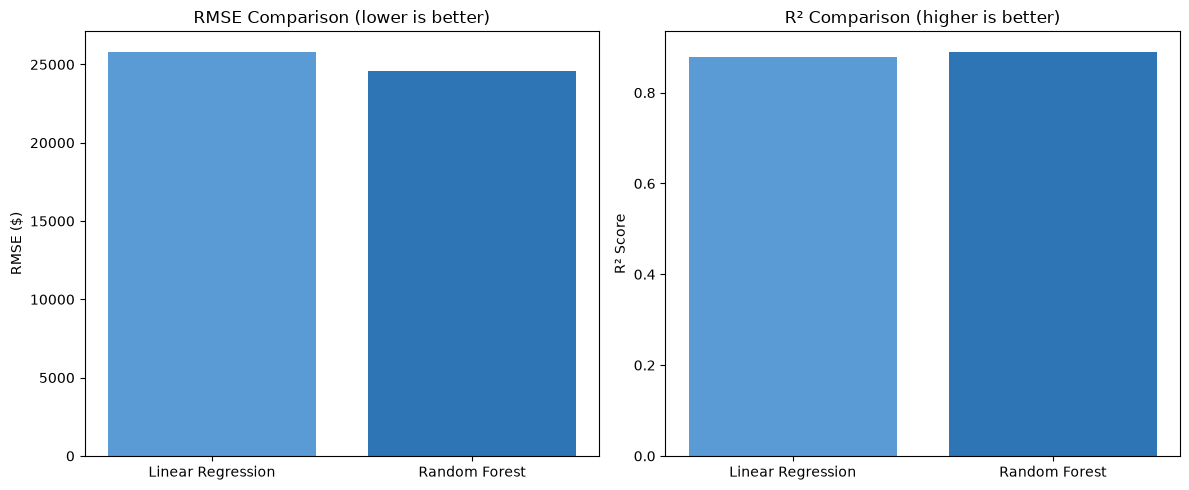

✅ Saved


In [4]:
# Bar chart comparing both models
models = ['Linear Regression', 'Random Forest']
rmse_scores = [lr_rmse, rf_rmse]
r2_scores = [lr_r2, rf_r2]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.bar(models, rmse_scores, color=['#5B9BD5', '#2E75B6'])
ax1.set_title('RMSE Comparison (lower is better)')
ax1.set_ylabel('RMSE ($)')

ax2.bar(models, r2_scores, color=['#5B9BD5', '#2E75B6'])
ax2.set_title('R² Comparison (higher is better)')
ax2.set_ylabel('R² Score')

plt.tight_layout()
plt.savefig('../images/05_model_comparison.png', dpi=150)
plt.show()
print("✅ Saved")

/var/folders/4s/nsmjrmn96tjf47kyt5dvy9800000gn/T/ipykernel_32615/1242583189.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top15.values, y=top15.index, palette='Blues_r')


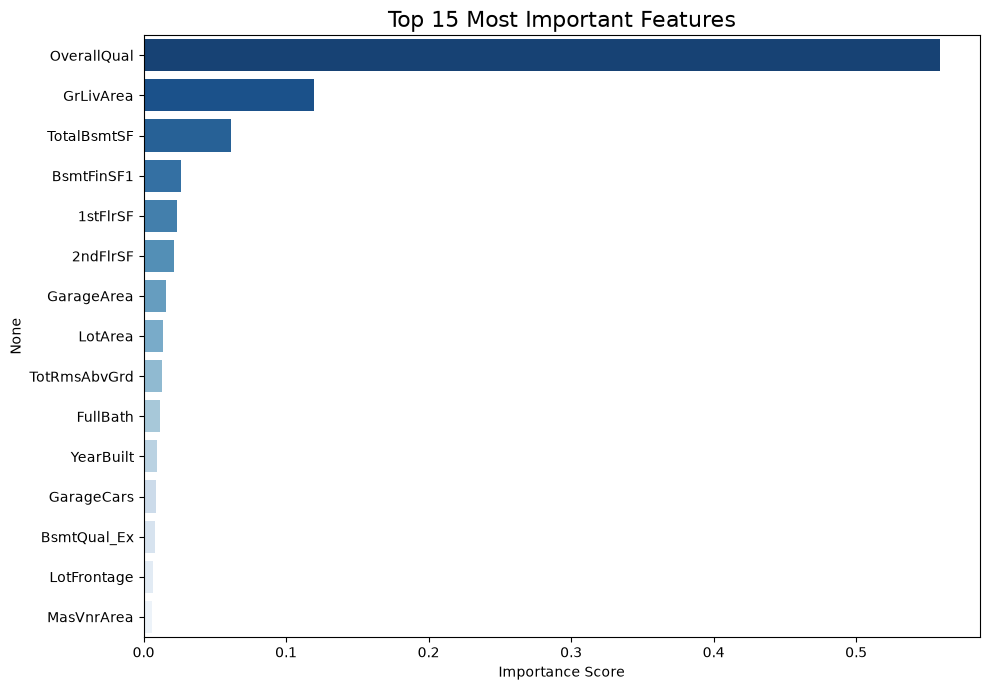

✅ Saved


In [5]:
# Which features matter most to the Random Forest?
feat_imp = pd.Series(rf.feature_importances_, index=X.columns)
top15 = feat_imp.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 7))
sns.barplot(x=top15.values, y=top15.index, palette='Blues_r')
plt.title('Top 15 Most Important Features', fontsize=16)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../images/06_feature_importance.png', dpi=150)
plt.show()
print("✅ Saved")

In [6]:
# Create a sample house using the average values
sample = X_test.iloc[0:1].copy()

predicted_price = rf.predict(sample)[0]
actual_price = y_test.iloc[0]

print("── Predicting a house price ──")
print(f"Predicted price: ${predicted_price:,.0f}")
print(f"Actual price:    ${actual_price:,.0f}")
print(f"Difference:      ${abs(predicted_price - actual_price):,.0f}")

── Predicting a house price ──
Predicted price: $212,113
Actual price:    $190,000
Difference:      $22,113
